# What is Feature Engineering?

Feature Engineering is the process of creating new meaningful features 
from existing raw data to improve model performance.

It is one of the most important steps in data science.

Better features → Better models.

![alt text](<https://media.geeksforgeeks.org/wp-content/uploads/20250701114435618562/feature-engineering.webp>)

It involves transforming raw data into meaningful inputs that improve model accuracy and overall performance. This step may include:

- Handling missing values  
- Encoding categorical variables  
- Scaling numerical features  
- Creating new features  
- Combining or transforming existing features  

Feature Engineering helps convert messy real-world data into a structured format that models can understand, ultimately leading to better predictions and improved model performance.

# Why Feature Engineering is Important

Feature engineering helps in:
- Improving model accuracy
- Capturing hidden relationships
- Reducing noise
- Increasing predictive power
- Making data more meaningful for algorithms

In real-world ML projects, feature engineering often gives more improvement than changing algorithms.

# Processes Involved in Feature Engineering:

Lets see various features involved in feature engineering:

![alt text](<https://media.geeksforgeeks.org/wp-content/uploads/20250701123223591115/processes.webp>)

## Types of Feature Engineering Techniques

### 1. Feature Creation
Feature creation involves generating new features using domain knowledge or by identifying patterns in the data.

- **Domain-specific**
  - Created using industry knowledge or business rules  
  - Example: Profit = Revenue − Cost  

- **Data-driven**
  - Derived by observing patterns in the dataset  
  - Example: Creating interaction terms between variables  

- **Synthetic**
  - Formed by combining existing features  
  - Example: BMI = Weight / Height²  

---

### 2. Feature Transformation
Feature transformation modifies existing features to improve model learning.

- **Normalization & Scaling**
  - Adjusts feature ranges for consistency  
  - Helps models converge faster  

- **Encoding**
  - Converts categorical variables into numerical form  
  - Example: One-Hot Encoding, Label Encoding  

- **Mathematical Transformations**
  - Applies transformations such as logarithmic, square root, or power transforms  
  - Useful for handling skewed data  

---

### 3. Feature Extraction
Feature extraction identifies meaningful representations of data, often reducing dimensionality.

- **Dimensionality Reduction**
  - Techniques like PCA reduce the number of features while preserving important information  

- **Aggregation & Combination**
  - Summing, averaging, or grouping features  
  - Simplifies the model and reduces noise  

---

### 4. Feature Selection
Feature selection involves choosing a subset of relevant features for model training.

- **Filter Methods**
  - Based on statistical measures (e.g., correlation, chi-square test)  

- **Wrapper Methods**
  - Select features based on model performance  

- **Embedded Methods**
  - Feature selection integrated within model training  
  - Example: Lasso Regression  

---

### 5. Feature Scaling
Feature scaling ensures that all features contribute equally to the model.

- **Min-Max Scaling**
  - Rescales values to a fixed range (e.g., 0 to 1)  

- **Standard Scaling**
  - Transforms data to have mean 0 and variance 1  

# Loading Dataset for Feature Engineering

We will use a structured dataset (e.g., Wine Quality dataset) 
to create new features and analyze their impact.

In [1]:
# Import required libraries
import numpy as  np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/home/fm-pc-lt-269/Desktop/data_science/notebooks/data/winequality-red.csv")

# Preview dataset structure
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Creating New Features (Feature Creation)

We can create new features using:

- Mathematical combinations
- Domain knowledge
- Interaction between variables
- Ratios
- Polynomial features

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# Example: Create a new feature as ratio of two numerical columns
# Example: Create interaction feature (feature1 * feature2)
# Example: Create aggregated feature
# Preview dataset after adding new features

df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

df[['fixed acidity','volatile acidity', 'citric acid', 'total_acidity', ]].head()

,fixed acidity,volatile acidity,citric acid,total_acidity
0,7.4,0.70,0.00,8.10
1,7.8,0.88,0.00,8.68
2,7.8,0.76,0.04,8.60
3,11.2,0.28,0.56,12.04
4,7.4,0.70,0.00,8.10


In [9]:
df['acidity_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1)

In [12]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,acidity_ratio,alcohol sulphates interaction
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68,4.148936,6.664
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.60,4.431818,6.370
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,12.04,8.750000,5.684
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264


In [11]:
df['alcohol sulphates interaction'] = df['alcohol'] * df['sulphates']

# Feature Transformation

Feature transformation changes the representation of data.

Examples:
- Log transformation
- Square root transformation
- Binning numerical variables
- Polynomial feature creation

Transformation can improve model performance.

In [14]:
df.skew().sort_values(ascending=False)

chlorides                        5.680347
residual sugar                   4.540655
sulphates                        2.428672
alcohol sulphates interaction    1.527016
total sulfur dioxide             1.515531
free sulfur dioxide              1.250567
fixed acidity                    0.982751
total_acidity                    0.961103
acidity_ratio                    0.935149
alcohol                          0.860829
volatile acidity                 0.671593
citric acid                      0.318337
quality                          0.217802
pH                               0.193683
density                          0.071288
dtype: float64

In [16]:
df['chlorides_log'] = np.log10(df['chlorides'])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,acidity_ratio,alcohol sulphates interaction,chlorides_log
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68,4.148936,6.664,-1.008774
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.60,4.431818,6.370,-1.036212
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,12.04,8.750000,5.684,-1.124939
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186


In [17]:
df.skew().sort_values(ascending=False)

chlorides                        5.680347
residual sugar                   4.540655
sulphates                        2.428672
chlorides_log                    1.745215
alcohol sulphates interaction    1.527016
total sulfur dioxide             1.515531
free sulfur dioxide              1.250567
fixed acidity                    0.982751
total_acidity                    0.961103
acidity_ratio                    0.935149
alcohol                          0.860829
volatile acidity                 0.671593
citric acid                      0.318337
quality                          0.217802
pH                               0.193683
density                          0.071288
dtype: float64

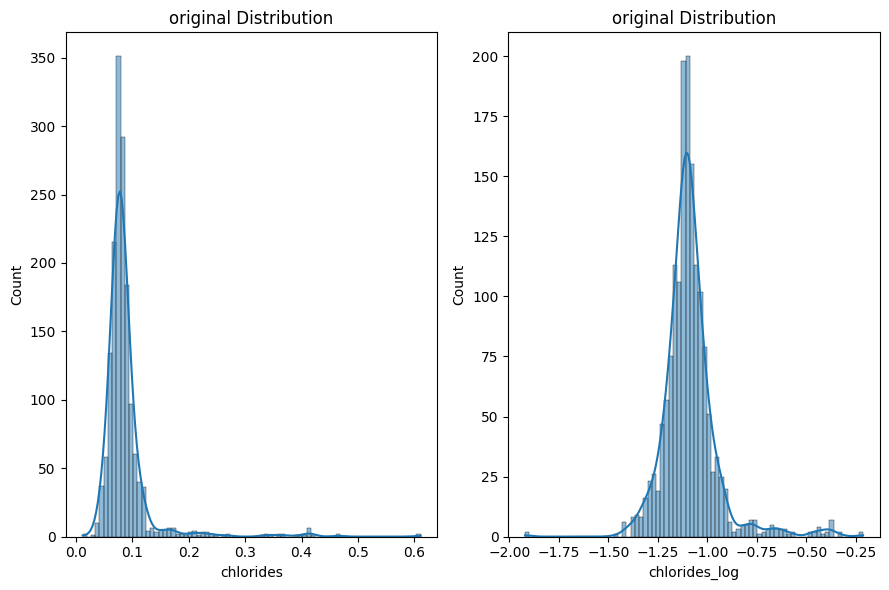

In [22]:
fig, axes = plt.subplots(1,2, figsize=(9,6))

sns.histplot(df['chlorides'], kde = True, ax = axes[0])
axes[0].set_title("original Distribution")

sns.histplot(df['chlorides_log'], kde = True, ax = axes[1])
axes[1].set_title("original Distribution")

plt.tight_layout()
plt.show()

# Binning (Discretization)

Binning converts continuous numerical data into categorical intervals.

Example:
Age → Young / Middle / Senior

Why useful?
- Simplifies model interpretation
- Handles non-linear relationships

In [24]:
df['alcohol'].max()

np.float64(14.9)

In [25]:
df['alcohol'].min()

np.float64(8.4)

In [27]:
# Use pd.cut() to create bins for a numerical feature
# Assign labels to bins
# Check distribution of binned feature

df['alcohol_level'] = pd.cut(
    df['alcohol'],
    bins=3,
    labels=['low', 'medium', 'high']
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,acidity_ratio,alcohol sulphates interaction,chlorides_log,alcohol_level
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68,4.148936,6.664,-1.008774,low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.60,4.431818,6.370,-1.036212,low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,12.04,8.750000,5.684,-1.124939,low
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,low


In [28]:
df['alcohol_level'].unique()

['low', 'medium', 'high']
Categories (3, str): ['low' < 'medium' < 'high']

# Polynomial Features 

Polynomial features capture non-linear relationships.

Example:
If X is a feature:
X², X³ are polynomial features.

Used when:
- Linear models fail to capture non-linearity

In [29]:
# Import PolynomialFeatures from sklearn
# Initialize PolynomialFeatures
# Generate polynomial features from selected columns
# Create new dataframe with polynomial features
df['alcohol_sqr'] = df['alcohol'] ** 2
df['alcohol_cubed'] = df['alcohol'] ** 3

In [30]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,acidity_ratio,alcohol sulphates interaction,chlorides_log,alcohol_level,alcohol_sqr,alcohol_cubed
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,low,88.36,830.584
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68,4.148936,6.664,-1.008774,low,96.04,941.192
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.60,4.431818,6.370,-1.036212,low,96.04,941.192
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,12.04,8.750000,5.684,-1.124939,low,96.04,941.192
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,low,88.36,830.584


# What is Feature Selection?

Feature Selection is the process of selecting the most important features 
and removing irrelevant or redundant features.

### Benefits of Feature Selection

- Removes irrelevant and redundant features  
- Improves model accuracy and reduces overfitting  
- Speeds up model training  
- Makes models simpler and easier to interpret

# Why Feature Selection is Necessary

Problems with too many features:
- Curse of dimensionality
- Increased noise
- Higher computational cost
- Risk of overfitting

`Not all features contribute equally to predictions.`

More Info : https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

# Correlation Matrix for Feature Selection

Highly correlated features can:
- Cause multicollinearity
- Reduce model stability (especially linear models)

We use correlation matrix to identify:
- Strong relationships
- Redundant features

In [31]:
df_num = df.select_dtypes(include=np.number)

df_num.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity,acidity_ratio,alcohol sulphates interaction,chlorides_log,alcohol_sqr,alcohol_cubed
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,88.36,830.584
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68,4.148936,6.664,-1.008774,96.04,941.192
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.60,4.431818,6.370,-1.036212,96.04,941.192
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,12.04,8.750000,5.684,-1.124939,96.04,941.192
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10,4.352941,5.264,-1.119186,88.36,830.584


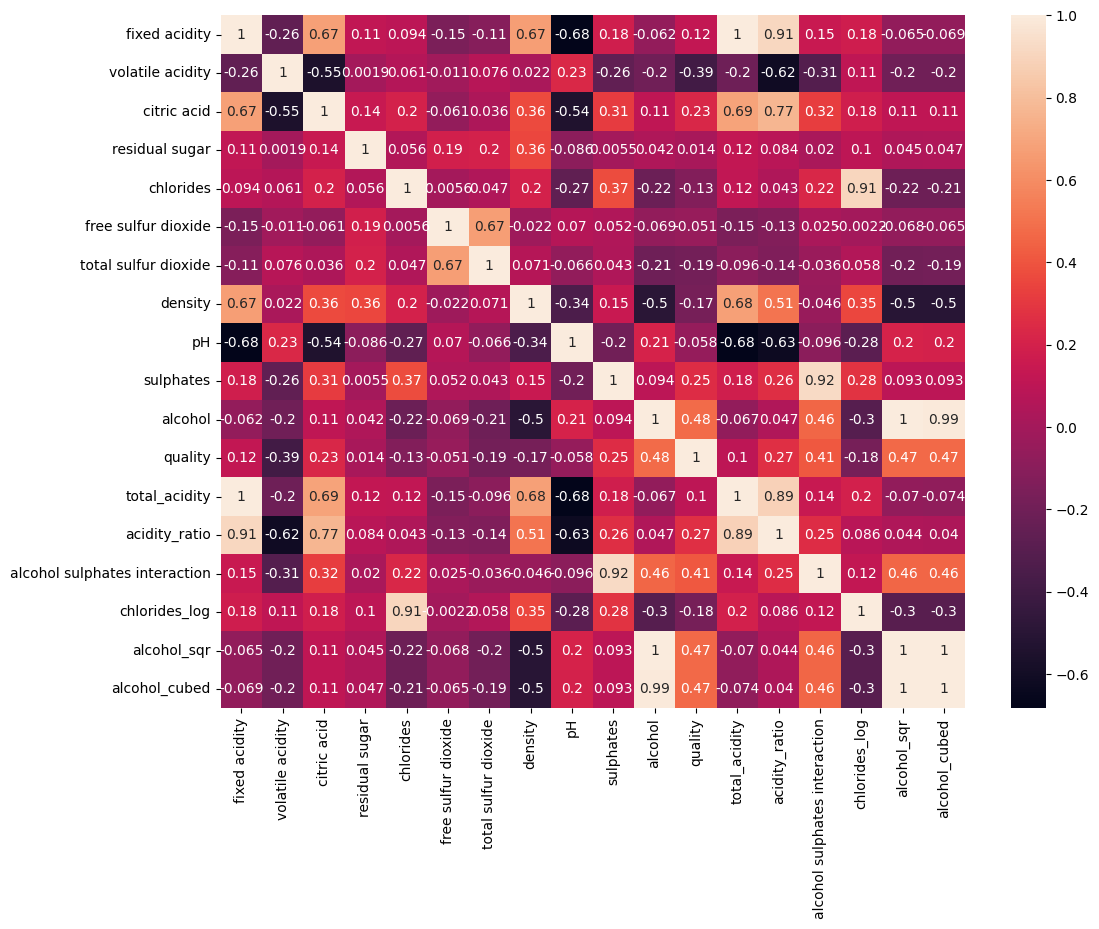

In [32]:
# Calculate correlation matrix
# Plot heatmap of correlation matrix
# Identify highly correlated feature pairs

corr_matrix = df_num.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot= True)
plt.show()

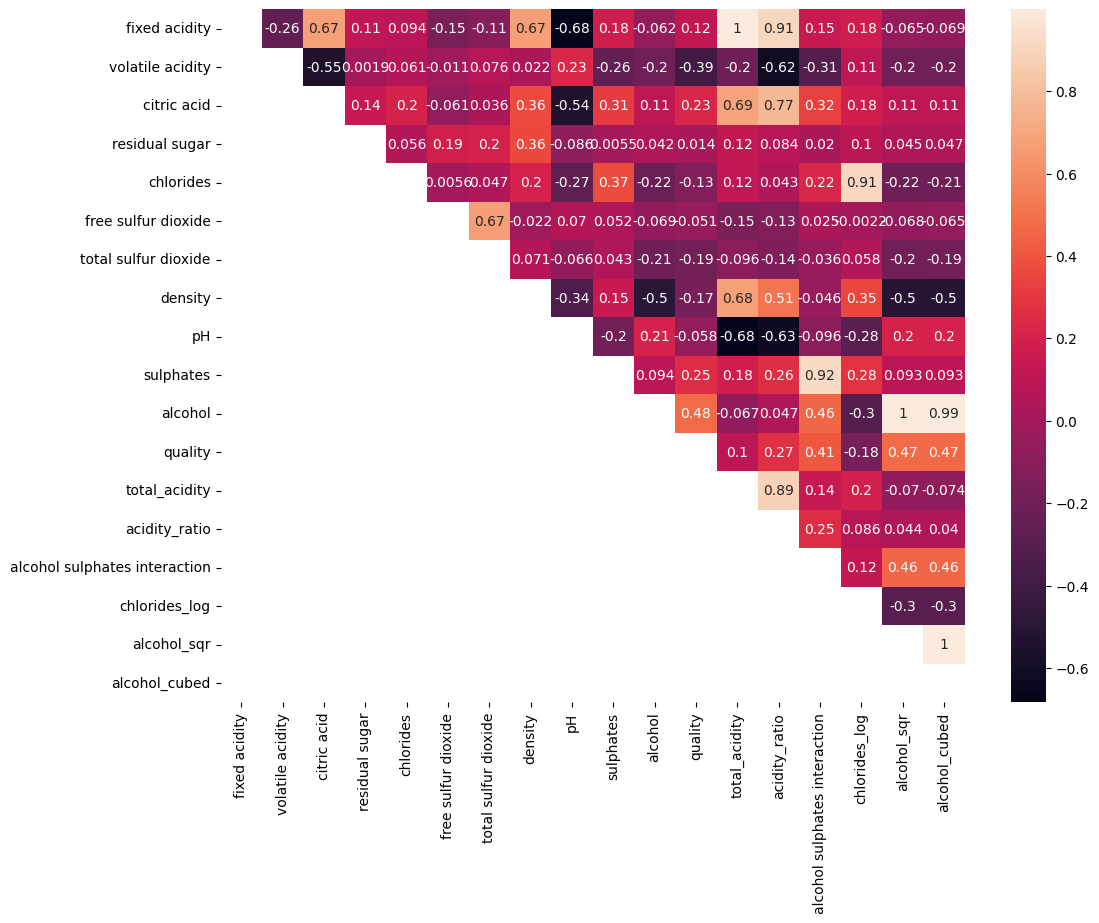

In [33]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
)

plt.figure(figsize=(12,9))
sns.heatmap(upper_triangle, annot= True)
plt.show()

In [34]:
threshold = 0.85

to_drop = [
    column for column in upper_triangle.columns 
    if any(upper_triangle[column] > threshold)
]
to_drop

['total_acidity',
 'acidity_ratio',
 'alcohol sulphates interaction',
 'chlorides_log',
 'alcohol_sqr',
 'alcohol_cubed']

# Removing Highly Correlated Features

If two features are highly correlated,
we may drop one of them to reduce redundancy.

In [35]:
df_reduced = df_num.drop(columns=to_drop)

In [38]:
df_reduced.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# Define correlation threshold (e.g., 0.8)

# Identify features above threshold

# Drop selected correlated features

# Create reduced dataset

## Types of Feature Selection Methods

Feature selection techniques are generally grouped into three main categories.  
Each method has its own strengths and trade-offs depending on the dataset, model type, and problem.


### 1. Filter Methods

Filter methods evaluate each feature independently with respect to the target variable.  
Features that show strong statistical relationships with the target are selected.

These methods are typically applied during the **data preprocessing stage** to remove irrelevant or redundant features before training the model.

#### Key Idea
- Measure the statistical relationship between each feature and the target variable.
- Select features with higher relevance.

### Common Filter Techniques

- **Information Gain**
  - Measures the reduction in entropy when a feature is used to split the data.
  - Higher information gain indicates a more informative feature.

- **Chi-Square Test**
  - Evaluates the relationship between categorical features and the target variable.
  - Commonly used for classification problems.

- **Fisher’s Score**
  - Ranks features based on their ability to separate different classes.

- **Pearson’s Correlation Coefficient**
  - Measures the linear relationship between two continuous variables.
  - Features with stronger correlation with the target are considered more useful.

- **Variance Threshold**
  - Removes features with very low variance.
  - Low variance features usually contain little useful information.

- **Mean Absolute Difference**
  - Similar to variance threshold but measures variability using absolute differences.

- **Dispersion Ratio**
  - Ratio of arithmetic mean to geometric mean.
  - Higher values indicate features with stronger discriminative power.


### Advantages

- **Fast and Efficient**
  - Computationally inexpensive and suitable for large datasets.

- **Easy to Implement**
  - Often available as built-in methods in machine learning libraries.

- **Model Independent**
  - Can be used with any machine learning algorithm.



### Limitations

- **Limited Interaction with the Model**
  - Since features are evaluated independently, important interactions between features may be missed.

- **Metric Selection**
  - Choosing the appropriate statistical metric for the dataset and task is important for optimal results.

![alt text](<https://media.geeksforgeeks.org/wp-content/uploads/20250830103247936857/filter.webp>)

## What is SelectKBest?

`SelectKBest` is a **filter-based feature selection method** available in `scikit-learn`.

It works by evaluating each feature using a statistical test and then selecting the **top K features** based on their scores.

### How it Works

1. **Score each feature**
   - A statistical function is applied to measure how strongly each feature is related to the target variable.

2. **Rank the features**
   - Features are ranked according to their computed scores.

3. **Select the top K features**
   - Only the **K highest-scoring features** are kept, while the others are removed.


### `score_func`

This parameter tells `SelectKBest` which **statistical scoring function** to use.

`f_regression` performs an **ANOVA F-test for regression problems**.

### What the F-test Measures

The F-test evaluates the **strength of the relationship between each feature and the target variable**.

- A **higher F-score** indicates a **stronger relationship** with the target.
- A **lower F-score** indicates the feature has **little influence** on the target.

### Interpretation

| F-score | Meaning |
|-------|--------|
| High | Feature strongly influences the target |
| Low | Feature has weak or little relationship with the target |

Features with the **highest F-scores** are selected as the most informative features for the model.

In [40]:
# Import SelectKBest from sklearn
# Apply feature selection using statistical test
# Select top k important features
# Create new dataset with selected features
from sklearn.feature_selection import SelectKBest, f_regression

x = df_reduced.drop(['quality'], axis = 1)
y = df_reduced['quality']

In [42]:
selector = SelectKBest(score_func=f_regression, k = 5)

X_selected = selector.fit_transform(x,y)

selected_features = x.columns[selector.get_support()]

selected_features

Index(['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates',
       'alcohol'],
      dtype='str')

In [43]:
df_selected = df_num[selected_features]
df_selected

,volatile acidity,citric acid,total sulfur dioxide,sulphates,alcohol
0,0.700,0.00,34.0,0.56,9.4
1,0.880,0.00,67.0,0.68,9.8
2,0.760,0.04,54.0,0.65,9.8
3,0.280,0.56,60.0,0.58,9.8
4,0.700,0.00,34.0,0.56,9.4
...,...,...,...,...,...
1594,0.600,0.08,44.0,0.58,10.5
1595,0.550,0.10,51.0,0.76,11.2
1596,0.510,0.13,40.0,0.75,11.0
1597,0.645,0.12,44.0,0.71,10.2


In [44]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(x)

selected_features = x.columns[selector.get_support()]

print("Selected Features after Variance Threshold:")
print(selected_features)

Selected Features after Variance Threshold:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates',
       'alcohol'],
      dtype='str')


### 2. Wrapper Methods

Wrapper methods use a machine learning model to evaluate different combinations of features and determine which subset produces the best model performance.

These methods work by repeatedly training a model using different feature subsets and measuring how well the model performs. Based on the results, features are added or removed. The process continues until a predefined stopping condition is reached, such as when model performance stops improving or when a desired number of features is selected.


### Common Wrapper Techniques

- **Forward Selection**
  - Starts with no features.
  - Features are added one by one based on which feature improves the model performance the most.

- **Backward Elimination**
  - Starts with all features.
  - The least useful features are removed step by step.

- **Recursive Feature Elimination (RFE)**
  - Trains a model and removes the least important feature at each step.
  - The process repeats until the desired number of features remains.



### Advantages

- **Model-specific optimization**

  - Wrapper methods evaluate features based on how they affect the model, which can lead to better predictive performance.

- **Flexible**
  - Can be used with different machine learning models and evaluation metrics.


### Limitations

- **Computationally expensive**
  - Evaluating many feature combinations requires repeatedly training models, which can be slow for large datasets.

- **Risk of overfitting**
  - Since the method optimizes features for a specific model, it may overfit and perform poorly on new unseen data.

![alt text](<https://media.geeksforgeeks.org/wp-content/uploads/20250830104446954251/wrapper.webp>)

### 3. Embedded Methods

Embedded methods perform feature selection during the model training process.  
They combine the advantages of both filter and wrapper methods by integrating feature selection directly into the learning algorithm.

During training, the model automatically identifies and selects the most relevant features based on their contribution to improving model performance.


### Common Embedded Techniques

- **L1 Regularization (Lasso)**
  - Shrinks some feature coefficients to zero.
  - Only features with non-zero coefficients remain in the model.

- **Decision Trees and Random Forests**
  - Select features based on impurity reduction (e.g., Gini importance or information gain).

- **Gradient Boosting**
  - Prioritizes features that reduce prediction error the most during boosting iterations.


### Advantages

- **Efficient and Effective**
  - Provides strong performance without the high computational cost of wrapper methods.

- **Model-Specific Learning**
  - Uses the model’s training process to automatically determine important features.


### Limitations

- **Limited Interpretability**
  - Harder to interpret compared to simple filter methods.

- **Not Universally Applicable**
  - Only certain machine learning algorithms support embedded feature selection techniques.

![alt text](<https://media.geeksforgeeks.org/wp-content/uploads/20250830104521819821/embedded.webp>)

## Choosing the Right Feature Selection Method

The choice of feature selection method depends on several factors:

- **Dataset Size**
  - Filter methods are generally faster and more suitable for large datasets.
  - Wrapper methods are often better suited for smaller datasets due to their higher computational cost.

- **Model Type**
  - Some models, such as tree-based models, have built-in feature selection mechanisms.

- **Interpretability**
  - If understanding why features were selected is important, filter methods are usually easier to interpret.

- **Computational Resources**
  - Wrapper methods require repeated model training and can be time-consuming.
  - Available computing power should be considered before choosing this approach.

Applying appropriate feature selection techniques can improve model performance, reduce noise, and lower computational cost.